# Ridge regression baseline for SFR surface density

Fits a single ridge regression on all galaxies combined:

$$\log_{10} \Sigma_{\rm SFR} = \mathbf{w} \cdot \log_{10}(\text{context features}) + b$$

Then shows the predictions per galaxy on the KS relation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Unit conversions from CGS
PC_TO_CM = 3.086e18
KPC_TO_CM = 3.086e21
MSOL_TO_G = 1.99e33
YR_TO_S = 3.15576e7

SURFDENS_TO_MSUN_PC2 = PC_TO_CM**2 / MSOL_TO_G
SFR_SURFDENS_TO_MSUN_YR_KPC2 = YR_TO_S * KPC_TO_CM**2 / MSOL_TO_G

CONTEXT_NAMES = ["gas_surfdens", "star_surfdens", "rotcurve", "kappa", "dm_voldens"]

In [2]:
SNAP_DIR = Path("../../snapshots")

galaxies = {
    "NGC300":   {"dir": "NGC300",   "pixel_pc": 80.0},
    "ETG-vlM":  {"dir": "ETG-vlM",  "pixel_pc": 80.0},
    "ETG-lowM": {"dir": "ETG-lowM", "pixel_pc": 80.0},
    "ETG-medM": {"dir": "ETG-medM", "pixel_pc": 80.0},
    "ETG-hiM":  {"dir": "ETG-hiM",  "pixel_pc": 80.0},
}

def load_galaxy(name, info):
    """Load all snapshots for one galaxy, return per-pixel context and SFR surface density."""
    snap_files = sorted((SNAP_DIR / info["dir"]).glob("sfr_context_*.npz"))
    pixel_area = (info["pixel_pc"] * PC_TO_CM) ** 2

    all_context = []
    all_sfr_surfdens = []

    for f in snap_files:
        d = np.load(f)
        context, sfr, pixel_id = d["context"], d["sfr"], d["pixel_id"]
        n_pixels = context.shape[0]

        sfr_sum = np.zeros(n_pixels)
        np.add.at(sfr_sum, pixel_id, sfr)
        sfr_surfdens = sfr_sum / pixel_area

        has_sf = sfr_surfdens > 0
        all_context.append(context[has_sf])
        all_sfr_surfdens.append(sfr_surfdens[has_sf])

    ctx = np.concatenate(all_context)
    sfr_sd = np.concatenate(all_sfr_surfdens)
    print(f"{name}: {len(snap_files)} snapshots, {len(sfr_sd)} star-forming pixels")
    return ctx, sfr_sd

data = {name: load_galaxy(name, info) for name, info in galaxies.items()}

NGC300: 31 snapshots, 40556 star-forming pixels
ETG-vlM: 31 snapshots, 12532 star-forming pixels
ETG-lowM: 31 snapshots, 28816 star-forming pixels
ETG-medM: 30 snapshots, 19053 star-forming pixels
ETG-hiM: 22 snapshots, 31052 star-forming pixels


In [3]:
# Combine all galaxies for fitting
all_ctx = np.concatenate([ctx for ctx, _ in data.values()])
all_sfr = np.concatenate([sfr for _, sfr in data.values()])

# Work in log-space; drop any rows with non-finite context values
log_ctx = np.log10(all_ctx)
log_sfr = np.log10(all_sfr)
finite = np.all(np.isfinite(log_ctx), axis=1) & np.isfinite(log_sfr)

X = log_ctx[finite]
y = log_sfr[finite]
print(f"Training samples: {len(y)} ({finite.sum() / len(finite) * 100:.1f}% of total)")

Training samples: 130715 (99.0% of total)


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/2734379756.py:6: RuntimeWarning: divide by zero encountered in log10
  log_ctx = np.log10(all_ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/2734379756.py:6: RuntimeWarning: invalid value encountered in log10
  log_ctx = np.log10(all_ctx)


In [4]:
# Fit ridge regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),
])
model.fit(X, y)

r2 = model.score(X, y)
print(f"R² = {r2:.4f}")

# Print coefficients in terms of original log-space features
coefs = model.named_steps["ridge"].coef_ / model.named_steps["scaler"].scale_
intercept = model.named_steps["ridge"].intercept_ - np.sum(
    model.named_steps["ridge"].coef_ * model.named_steps["scaler"].mean_ / model.named_steps["scaler"].scale_
)
print(f"\nlog Σ_SFR = {intercept:.3f}", end="")
for name, c in zip(CONTEXT_NAMES, coefs):
    print(f" {'+' if c >= 0 else '-'} {abs(c):.3f} log({name})", end="")
print()

R² = 0.2464

log Σ_SFR = -24.578 + 3.178 log(gas_surfdens) - 0.008 log(star_surfdens) + 0.924 log(rotcurve) - 0.030 log(kappa) - 0.219 log(dm_voldens)


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/299569314.py:12: RuntimeWarning: divide by zero encountered in log10
  log_ctx_gal = np.log10(ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/299569314.py:12: RuntimeWarning: invalid value encountered in log10
  log_ctx_gal = np.log10(ctx)


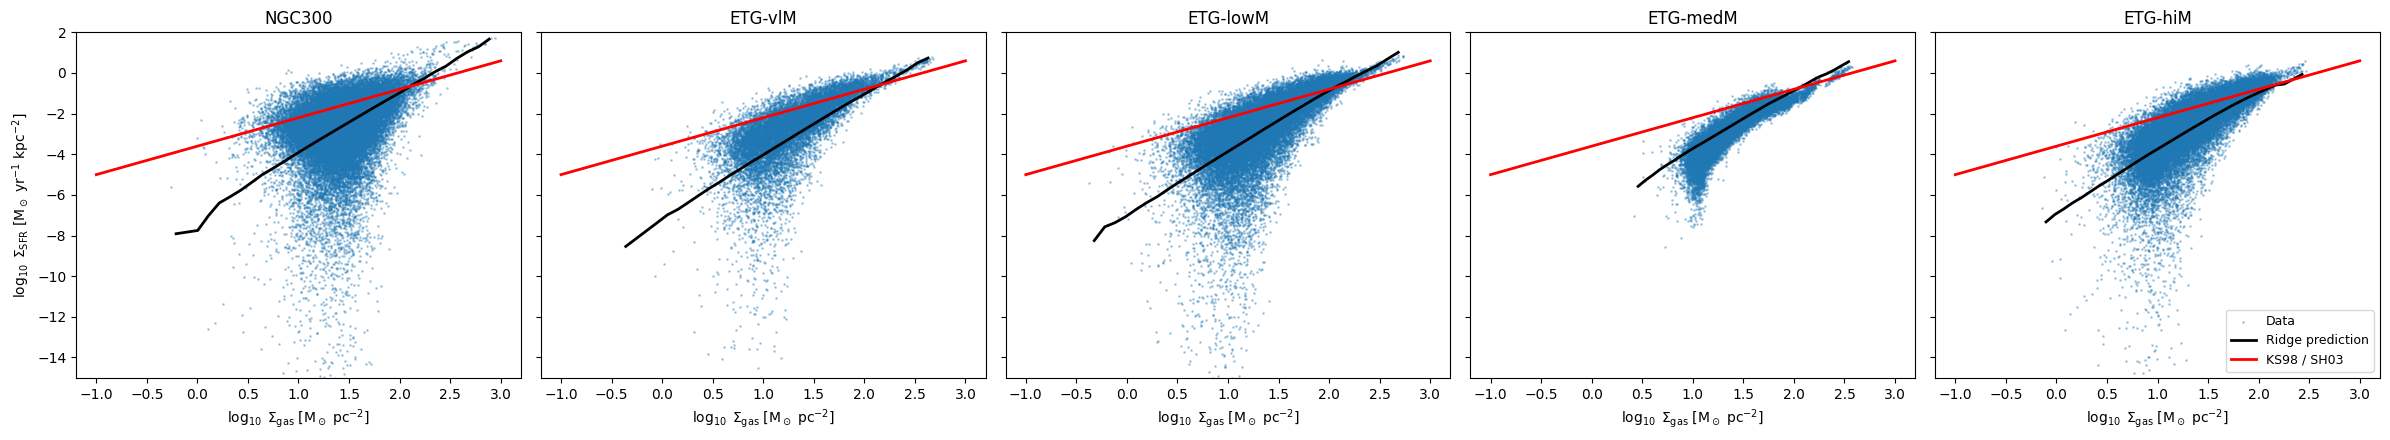

In [5]:
# KS98 line
sig_gas_ks = np.logspace(-1, 3, 200)
sig_sfr_ks = 2.5e-4 * sig_gas_ks**1.4

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for ax, (name, (ctx, sfr_sd)) in zip(axes, data.items()):
    log_gas = np.log10(ctx[:, 0] * SURFDENS_TO_MSUN_PC2)
    log_sfr_actual = np.log10(sfr_sd * SFR_SURFDENS_TO_MSUN_YR_KPC2)

    # Predict
    log_ctx_gal = np.log10(ctx)
    finite_gal = np.all(np.isfinite(log_ctx_gal), axis=1)
    log_sfr_pred = np.full(len(ctx), np.nan)
    log_sfr_pred[finite_gal] = model.predict(log_ctx_gal[finite_gal])
    # Convert prediction from CGS log to physical units log
    log_sfr_pred_phys = log_sfr_pred + np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)

    # Scatter of actual data
    ax.scatter(log_gas, log_sfr_actual, s=1, alpha=0.3, label="Data")

    # Binned mean of ridge predictions vs gas surface density
    valid_pred = np.isfinite(log_sfr_pred_phys)
    log_gas_v = log_gas[valid_pred]
    log_pred_v = log_sfr_pred_phys[valid_pred]
    bin_edges = np.linspace(log_gas_v.min(), log_gas_v.max(), 31)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_means = np.full(30, np.nan)
    for i in range(30):
        in_bin = (log_gas_v >= bin_edges[i]) & (log_gas_v < bin_edges[i + 1])
        if in_bin.sum() > 0:
            bin_means[i] = np.mean(log_pred_v[in_bin])
    ok = np.isfinite(bin_means)
    ax.plot(bin_centers[ok], bin_means[ok], "k-", lw=2, label="Ridge prediction")

    # KS98 line
    ax.plot(np.log10(sig_gas_ks), np.log10(sig_sfr_ks), "r-", lw=2, label="KS98 / SH03")

    ax.set_title(name)
    ax.set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylim([-15., 2.])
axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
axes[-1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

In [6]:
# R² per galaxy: ridge regression vs KS98
from sklearn.metrics import r2_score

print(f"{'Galaxy':<12} {'R² (Ridge)':>12} {'R² (KS98)':>12}")
print("-" * 38)

for name, (ctx, sfr_sd) in data.items():
    log_sfr_actual = np.log10(sfr_sd)

    # Ridge R²
    log_ctx_gal = np.log10(ctx)
    finite_gal = np.all(np.isfinite(log_ctx_gal), axis=1)
    r2_ridge = r2_score(
        log_sfr_actual[finite_gal],
        model.predict(log_ctx_gal[finite_gal]),
    )

    # KS98 R²: log Σ_SFR = log(2.5e-4) + 1.4 * log Σ_gas, converted to CGS
    log_gas_msun_pc2 = np.log10(ctx[finite_gal, 0] * SURFDENS_TO_MSUN_PC2)
    log_sfr_ks_msun = np.log10(2.5e-4) + 1.4 * log_gas_msun_pc2  # in Msun/yr/kpc^2
    log_sfr_ks_cgs = log_sfr_ks_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    r2_ks = r2_score(log_sfr_actual[finite_gal], log_sfr_ks_cgs)

    print(f"{name:<12} {r2_ridge:>12.4f} {r2_ks:>12.4f}")

Galaxy         R² (Ridge)    R² (KS98)
--------------------------------------
NGC300             0.0512      -0.1681
ETG-vlM            0.3651      -0.0102
ETG-lowM           0.2871      -0.0084
ETG-medM           0.7091      -0.7564
ETG-hiM            0.4496       0.0109


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/3595990523.py:11: RuntimeWarning: divide by zero encountered in log10
  log_ctx_gal = np.log10(ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/3595990523.py:11: RuntimeWarning: invalid value encountered in log10
  log_ctx_gal = np.log10(ctx)


In [7]:
# Gaussian NLL per galaxy: assume residuals are Gaussian with variance estimated from training set
# NLL = 0.5 * log(2π σ²) + 0.5 * (y - ŷ)² / σ²

# Estimate σ² from full training set for each model
ridge_residuals = y - model.predict(X)
ridge_var = np.var(ridge_residuals)

log_gas_all_msun = np.log10(all_ctx[finite, 0] * SURFDENS_TO_MSUN_PC2)
ks_pred_all = np.log10(2.5e-4) + 1.4 * log_gas_all_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
ks_residuals = y - ks_pred_all
ks_var = np.var(ks_residuals)

print(f"Training set σ²:  Ridge = {ridge_var:.4f},  KS98 = {ks_var:.4f}")
print()
print(f"{'Galaxy':<12} {'NLL (Ridge)':>12} {'NLL (KS98)':>12}")
print("-" * 38)

for name, (ctx, sfr_sd) in data.items():
    log_sfr_actual = np.log10(sfr_sd)
    log_ctx_gal = np.log10(ctx)
    finite_gal = np.all(np.isfinite(log_ctx_gal), axis=1)
    y_true = log_sfr_actual[finite_gal]
    n = y_true.shape[0]

    # Ridge NLL
    y_pred_ridge = model.predict(log_ctx_gal[finite_gal])
    nll_ridge = 0.5 * np.log(2 * np.pi * ridge_var) + 0.5 * np.mean((y_true - y_pred_ridge)**2) / ridge_var

    # KS98 NLL
    log_gas_msun = np.log10(ctx[finite_gal, 0] * SURFDENS_TO_MSUN_PC2)
    y_pred_ks = np.log10(2.5e-4) + 1.4 * log_gas_msun - np.log10(SFR_SURFDENS_TO_MSUN_YR_KPC2)
    nll_ks = 0.5 * np.log(2 * np.pi * ks_var) + 0.5 * np.mean((y_true - y_pred_ks)**2) / ks_var

    print(f"{name:<12} {nll_ridge:>12.4f} {nll_ks:>12.4f}")

Training set σ²:  Ridge = 3.3020,  KS98 = 3.6175

Galaxy        NLL (Ridge)   NLL (KS98)
--------------------------------------
NGC300             2.3611       2.5113
ETG-vlM            1.8664       2.0703
ETG-lowM           2.1547       2.3863
ETG-medM           1.5745       1.8830
ETG-hiM            1.7830       1.9996


/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/1910977375.py:20: RuntimeWarning: divide by zero encountered in log10
  log_ctx_gal = np.log10(ctx)
/var/folders/30/hdkspf4j307b3qg9j5yb_cgm0000gp/T/ipykernel_20042/1910977375.py:20: RuntimeWarning: invalid value encountered in log10
  log_ctx_gal = np.log10(ctx)
